In [1]:


import geopandas as gps
from osgeo import gdal
import fiona

import shapely

from tqdm import tqdm_notebook as tqdm

import rasterio

from shapely.geometry import box, Point
import rasterio.mask
import json
import os
from PIL import Image
import PIL.ImageDraw
import numpy as np

In [58]:
from functools import singledispatch
from itertools import chain
from typing import (List, 
                    Tuple,
                    TypeVar)

from shapely.geometry import (GeometryCollection,
                              LinearRing,
                              LineString,
                              Point,
                              Polygon)
from shapely.geometry.base import (BaseGeometry,
                                   BaseMultipartGeometry)

Geometry = TypeVar('Geometry', bound=BaseGeometry)


@singledispatch
def to_coords(geometry: Geometry) -> List[Tuple[float, float]]:
    """Returns a list of unique vertices of a given geometry object."""
    raise NotImplementedError(f"Unsupported Geometry {type(geometry)}")


@to_coords.register
def _(geometry: Point):
    return [(geometry.x, geometry.y)]


@to_coords.register
def _(geometry: LineString):
    return list(geometry.coords)


@to_coords.register
def _(geometry: LinearRing):
    return list(geometry.coords[:-1])


@to_coords.register
def _(geometry: BaseMultipartGeometry):
    return list(set(chain.from_iterable(map(to_coords, geometry))))


@to_coords.register
def _(geometry: Polygon):
    return to_coords(GeometryCollection([geometry.exterior, *geometry.interiors]))

In [98]:
def drawPolygons(polygons, shape, outline, fill):
    """
    From the polygons, create a numpy mask with fill value in the foreground and 0 value in the background.
    Outline (i.e the edge of the polygon) can be assigned a separate value.
    """
    mask = np.zeros(shape, dtype=np.uint8)
    mask = PIL.Image.fromarray(mask)
    draw = PIL.ImageDraw.Draw(mask)
    #Syntax: PIL.ImageDraw.Draw.polygon(xy, fill=None, outline=None)
    #Parameters:
    #xy – Sequence of either 2-tuples like [(x, y), (x, y), …] or numeric values like [x, y, x, y, …].
    #outline – Color to use for the outline.
    #fill – Color to use for the fill.
    #Returns: An Image object.
    for polygon in polygons:
        xy = [(point[1], point[0]) for point in polygon]
        draw.polygon(xy=xy, outline=outline, fill=fill)
    mask = np.array(mask)#, dtype=bool)   
    return(mask)

def rowColPolygons(areaDf, areaShape, profile, filename, outline, fill):
    """
    Convert polygons coordinates to image pixel coordinates, create annotation image using drawPolygons() 
    and write the results into an image file.
    """
    transform = profile['transform']
    polygons = []
    gm = areaDf.geometry
    for i in range(len(gm)):
        #coords = to_coords(gm.loc[i])
        #ty = gm.loc[i].type=='MultiPolygon'
        if gm.loc[i].type=='MultiPolygon':
            coords = [point for polygon in gm.loc[i] for point in polygon.exterior.coords[:-1]]
            m = []
            n = []
            for a, b in coords:
                m.append(a)
                n.append(b)
            m = tuple(m)
            n = tuple(n)
        else:
            m,n = zip(*list(gm.loc[i].exterior.coords))
        row, col = rasterio.transform.rowcol(transform, m, n)
        zipped = list(zip(row,col))
        #a,b = zip(*list(gm.exterior.coords))
        #row, col = rasterio.transform.rowcol(transform, a, b)
        #zipped = list(zip(row,col)) #[list(rc) for rc in list(zip(row,col))]
        polygons.append(zipped)

    with open(filename, 'w') as outfile:  
        json.dump({'Trees': polygons}, outfile)
    mask = drawPolygons(polygons,areaShape, outline=outline, fill=fill)    
    profile['dtype'] = rasterio.int16
    with rasterio.open(filename.replace('json', 'png'), 'w', **profile) as dst:
        dst.write(mask.astype(rasterio.int16), 1)

In [91]:
#training_polygon_list
shp_path = r"K:\china_label_shp"
shp_list = os.listdir(shp_path)
training_polygon_list = [shp for shp in shp_list if shp.startswith('clip') and shp.endswith('.shp')]
tif_path = r'K:\done'
tif_list = os.listdir(tif_path)
ndwi_list = [tif for tif in tif_list if tif.startswith('ndwi') and tif.endswith('.tif')]


In [4]:
print(len(ndwi_list),len(training_polygon_list))

499 498


In [5]:
for index, item in enumerate(ndwi_list):
    a = os.path.splitext(item)[0]
    b = 0
    for index2, item2 in enumerate(training_polygon_list):
        if item2.find(a) != -1:

            trainingPolygon = gps.read_file(os.path.join(shp_path,item2))
            ndwi = rasterio.open(os.path.join(tif_path,item))
            
            annotation_json_filepath=os.path.splitext(os.path.join(shp_path,item2))[0]+'.json'
            rowColPolygons(trainingPolygon,(ndwi.height,ndwi.width), ndwi.profile, annotation_json_filepath, outline = 0, fill = 1)


AttributeError: 'MultiPolygon' object has no attribute 'exterior'

In [99]:
ttt = gps.read_file(r"K:\china_label_shp\clip_ndwi1_int8_china_101_2.shp")
yyy = rasterio.open(r"K:\done\ndwi1_int8_china_101_2.tif")
annotation_json_filepath = r"K:\china_label_shp\clip_ndwi1_int8_china_101_2.json"

In [101]:
rowColPolygons(ttt,(yyy.height,yyy.width), yyy.profile, annotation_json_filepath, outline = 0, fill = 1)

In [65]:
transform = ndwi.profile['transform']
for geo in ge:
    coords = to_coords(geo)
    for a, b in coords:
        row, col = rasterio.transform.rowcol(transform, a, b)
        zipped = list(zip(row,col))
zipped

TypeError: 'int' object is not iterable

In [79]:
to_coords

[(120.46733343841697, 32.54928651020151),
 (120.43048260880198, 32.586656426021136),
 (120.4172773741252, 32.534643971070466),
 (120.45104753482417, 32.54361806655021),
 (120.48438152584902, 32.54551358600821),
 (120.46237280138803, 32.54757971116163),
 (120.4219486136027, 32.551711961468925),
 (120.43299789159755, 32.56886978339554),
 (120.45913886636515, 32.572822370645724),
 (120.42563170626795, 32.59510058969181),
 (120.47387123702504, 32.579020746106096),
 (120.42733850530783, 32.59339379065193),
 (120.42850631517683, 32.592136149254145),
 (120.42794788601009, 32.56211788808105),
 (120.43209957631314, 32.54084234653084),
 (120.47441022619546, 32.565905342957876),
 (120.42320625500065, 32.55180179299725),
 (120.42239777124485, 32.53697959080915),
 (120.49363417327538, 32.6000413237544),
 (120.4746797207805, 32.61144992786279),
 (120.43102159797263, 32.58575811073695),
 (120.4506048711662, 32.57147489771944),
 (120.4150315859149, 32.532128688274895),
 (120.49733431730158, 32.5949242

In [38]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [22]:
a = ge.type == 'MultiPolygon'


a.all()

True

In [81]:
ge = trainingPolygon.geometry
ttt = gps.read_file(r"K:\china_label_shp\clip_ndwi1_int8_china_101_2.shp")
ge1 = ttt.geometry
co = to_coords(ge1.loc[0])
len(co)
co1 = to_coords(ge1.loc[1])
len(co1)
coo = [point for polygon in ge1.loc[0] for point in polygon.exterior.coords[:-1]]
len(coo)
for geee in ge1:
    co1 =  to_coords(geee)
len(co1)

54

834

56

750

In [62]:
ttt = gps.read_file(r"K:\china_label_shp\clip_ndwi1_int8_china_0_1.shp")
ttt['geometry']
for geo in ge:
    coords = to_coords(geo)
coords

0    POLYGON ((110.12249 18.93828, 110.12267 18.938...
1    POLYGON ((110.10848 18.89220, 110.10857 18.892...
2    POLYGON ((110.10911 18.89130, 110.10920 18.891...
3    POLYGON ((110.10929 18.89121, 110.10974 18.891...
4    POLYGON ((110.11073 18.89121, 110.11082 18.891...
5    POLYGON ((110.11064 18.89112, 110.11073 18.891...
6    POLYGON ((110.11010 18.89103, 110.11028 18.891...
7    POLYGON ((110.11127 18.89175, 110.11145 18.891...
8    POLYGON ((110.11136 18.89058, 110.11145 18.890...
9    POLYGON ((110.11118 18.89031, 110.11127 18.890...
Name: geometry, dtype: geometry

[(120.46733343841697, 32.54928651020151),
 (120.43048260880198, 32.586656426021136),
 (120.4172773741252, 32.534643971070466),
 (120.45104753482417, 32.54361806655021),
 (120.48438152584902, 32.54551358600821),
 (120.46237280138803, 32.54757971116163),
 (120.4219486136027, 32.551711961468925),
 (120.43299789159755, 32.56886978339554),
 (120.45913886636515, 32.572822370645724),
 (120.42563170626795, 32.59510058969181),
 (120.47387123702504, 32.579020746106096),
 (120.42733850530783, 32.59339379065193),
 (120.42850631517683, 32.592136149254145),
 (120.42794788601009, 32.56211788808105),
 (120.43209957631314, 32.54084234653084),
 (120.47441022619546, 32.565905342957876),
 (120.42320625500065, 32.55180179299725),
 (120.42239777124485, 32.53697959080915),
 (120.49363417327538, 32.6000413237544),
 (120.4746797207805, 32.61144992786279),
 (120.43102159797263, 32.58575811073695),
 (120.4506048711662, 32.57147489771944),
 (120.4150315859149, 32.532128688274895),
 (120.49733431730158, 32.5949242

0    MULTIPOLYGON (((120.41422 32.53114, 120.41422 ...
Name: geometry, dtype: geometry

0    POLYGON ((120.41395 32.53105, 120.41332 32.551...
dtype: geometry

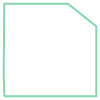

0    []
dtype: object

0    LINESTRING (120.41395 32.53105, 120.41332 32.5...
dtype: geometry

In [56]:
ge
ge.convex_hull
ge.convex_hull.exterior[0]
ge.convex_hull.interiors
ge.convex_hull.boundary


In [8]:
trainingPolygon = gps.read_file(os.path.join(shp_path,item2))
ge = trainingPolygon['geometry']
if ge.type == 'Polygon':
    a,b = zip(*list(ge.exterior.coords))

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [26]:
#a,b = zip(*list(gm.exterior.coords))
a = ge.type=='MultiPolygon'
if a.bool():
    all_xy = []
    for ea in ge:
        all_xy.append(list( ea.exterior.coords.xy[0] ))


AttributeError: 'MultiPolygon' object has no attribute 'exterior'

In [ ]:
def getPolyCoords(row, geom, coord_type):
    """Returns the coordinates ('x|y') of edges/vertices of a Polygon/others"""

    # Parse the geometries and grab the coordinate
    geometry = row[geom]
    #print(geometry.type)

    if geometry.type=='Polygon':
        if coord_type == 'x':
            # Get the x coordinates of the exterior
            # Interior is more complex: xxx.interiors[0].coords.xy[0]
            return list( geometry.exterior.coords.xy[0] )
        elif coord_type == 'y':
            # Get the y coordinates of the exterior
            return list( geometry.exterior.coords.xy[1] )

    if geometry.type in ['Point', 'LineString']:
        if coord_type == 'x':
            return list( geometry.xy[0] )
        elif coord_type == 'y':
            return list( geometry.xy[1] )

    if geometry.type=='MultiLineString':
        all_xy = []
        for ea in geometry:
            if coord_type == 'x':
                all_xy.append(list( ea.xy[0] ))
            elif coord_type == 'y':
                all_xy.append(list( ea.xy[1] ))
        return all_xy

    if geometry.type=='MultiPolygon':
        all_xy = []
        for ea in geometry:
            if coord_type == 'x':
                all_xy.append(list( ea.exterior.coords.xy[0] ))
            elif coord_type == 'y':
                all_xy.append(list( ea.exterior.coords.xy[1] ))
        return all_xy

    else:
        # Finally, return empty list for unknown geometries
        return []

In [84]:
co

[(120.07483958781904, 32.96350159127826),
 (120.07331245183582, 32.963860917391855),
 (120.07313278877939, 32.963860917391855),
 (120.07474975629088, 32.96529822184647),
 (120.07412093559185, 32.96377108586347),
 (120.07303708819643, 32.96401511763656),
 (120.07457009323377, 32.964489738090606),
 (120.07483958781904, 32.96520839031797),
 (120.07457009323377, 32.96350159127826),
 (120.07394127253508, 32.963860917391855),
 (120.07492941934777, 32.96520839031797),
 (120.07448026170516, 32.96359142280659),
 (120.07483958781904, 32.963321928221376),
 (120.07358194642131, 32.96377108586347),
 (120.07457009323377, 32.96457956961916),
 (120.07439043017712, 32.96359142280659),
 (120.07439043017712, 32.963860917391855),
 (120.07465992476239, 32.96431007503395),
 (120.07304422657933, 32.96395801057241),
 (120.07448026170516, 32.96404058044868),
 (120.07349211489316, 32.96377108586347),
 (120.07358194642131, 32.963860917391855),
 (120.07483958781904, 32.96484906420437),
 (120.07474975629088, 32.96

In [83]:
coo

[(120.07313278877939, 32.96395074892018),
 (120.07331245183582, 32.96395074892018),
 (120.07331245183582, 32.963860917391855),
 (120.07313278877939, 32.963860917391855),
 (120.07295856598284, 32.96389376512525),
 (120.07296570436597, 32.96397942572156),
 (120.07289432053585, 32.96399370248747),
 (120.07289432053585, 32.964029394402644),
 (120.07303708819643, 32.96401511763656),
 (120.07304422657933, 32.96395801057241),
 (120.07465992476239, 32.96457956961916),
 (120.07465992476239, 32.96431007503395),
 (120.07457009323377, 32.96431007503395),
 (120.07457009323377, 32.96404058044868),
 (120.07448026170516, 32.96404058044868),
 (120.07448026170516, 32.96359142280659),
 (120.07457009323377, 32.96359142280659),
 (120.07457009323377, 32.96352068327542),
 (120.07459360408347, 32.96350159127826),
 (120.07483958781904, 32.96350159127826),
 (120.07483958781904, 32.963321928221376),
 (120.07474975629088, 32.963321928221376),
 (120.07474975629088, 32.96314226516449),
 (120.07457009323377, 32.9631

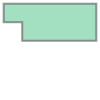

In [23]:
trainingPolygon = gps.read_file(os.path.join(shp_path,item2))
trainingPolygon.loc[1]['geometry']

In [4]:
trainingArea = gps.read_file(r"E:\zwk\tree\1024.shp")
trainingPolygon = gps.read_file(r"E:\zwk\tree\clip_ndwi1_int8_china_0_1.shp")

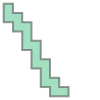

In [5]:
trainingPolygon.loc[1]['geometry']

In [6]:
if trainingArea.crs  != trainingPolygon.crs:
    print('Training area CRS does not match training_polygon CRS')
    targetCRS = trainingPolygon.crs #Areas are less in number so conversion should be faster
    trainingArea = trainingArea.to_crs(targetCRS)
print(trainingPolygon.crs)
print(trainingArea.crs)
assert trainingPolygon.crs == trainingArea.crs

epsg:4326
epsg:4326


In [8]:
trainingArea.shape[0]
trainingArea['id'] = range(trainingArea.shape[0])

In [11]:
def dividePolygonsInTrainingAreas(trainingPolygon, trainingArea):
    '''
    Assign annotated ploygons in to the training areas.
    '''
    # For efficiency, assigned polygons are removed from the list, we make a copy here. 
    cpTrainingPolygon = trainingPolygon.copy()
    splitPolygons = {}
    for i in tqdm(trainingArea.index):
        spTemp = []
        allocated = []
        for j in cpTrainingPolygon.index:
            if trainingArea.loc[i]['geometry'].intersects(cpTrainingPolygon.loc[j]['geometry']):
                spTemp.append(cpTrainingPolygon.loc[j])
                allocated.append(j)

            # Order of bounds: minx miny maxx maxy
        #boundary = calculateBoundaryWeight(spTemp, scale_polygon = 1.5, output_plot = config.show_boundaries_during_processing)
        splitPolygons[trainingArea.loc[i]['id']] = {'polygons':spTemp,  'bounds':list(trainingArea.bounds.loc[i]),}
        cpTrainingPolygon = cpTrainingPolygon.drop(allocated)
    return splitPolygons

# areasWithPolygons contains the object polygons and weighted boundaries for each area!
areasWithPolygons = dividePolygonsInTrainingAreas(trainingPolygon, trainingArea)
print(f'Assigned training polygons in {len(areasWithPolygons)} training areas and created weighted boundaries for ploygons')

<ipython-input-11-598c262b2056>:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm(trainingArea.index):


  0%|          | 0/759 [00:00<?, ?it/s]

Assigned training polygons in 759 training areas and created weighted boundaries for ploygons


In [18]:
ndwi = rasterio.open(r"E:\zwk\tree\clip_ndwi1_int8_china_0_1.tif")
ndwi.profile
ndwi.shape[1]
ndwi.bounds

BoundingBox(left=110.06257675713631, bottom=18.88159912537981, right=110.1226740496439, top=18.941606586358994)

In [20]:
annotation_json_filepath=r"E:\zwk\tree\clip_ndwi1_int8_china_0_1.json"

In [24]:
for areaID, areaInfo in areasWithPolygons.items():
    polygonsInAreaDf = gps.GeoDataFrame(areaInfo['polygons'])
    bboxArea = box(*areaInfo['bounds'])
    bboxImg = box(*ndwi.bounds)
    if(bboxArea.intersects(bboxImg)):
        profile = ndwi.profile  
        sm = rasterio.mask.mask(ndwi, [bboxArea], all_touched=True, crop=True )
        profile['height'] = sm[0].shape[1]
        profile['width'] = sm[0].shape[2]
        profile['transform'] = sm[1]
            # That's a problem with rasterio, if the height and the width are less then 256 it throws: ValueError: blockysize exceeds raster height 
            # So I set the blockxsize and blockysize to prevent this problem
        profile['blockxsize'] = 32
        profile['blockysize'] = 32
        profile['count'] = 1
        profile['dtype'] = rasterio.float32
        rowColPolygons(polygonsInAreaDf,(sm[0].shape[1], sm[0].shape[2]), profile, annotation_json_filepath, outline=0, fill = 1) 
   

In [26]:
np.array(ndwi)

array(<open DatasetReader name='E:\zwk\tree\clip_ndwi1_int8_china_0_1.tif' mode='r'>,
      dtype=object)

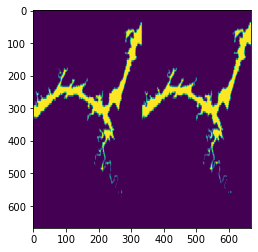

In [28]:
ano = Image.open(r"E:\zwk\tree\clip_ndwi1_int8_china_0_1.png")
reada = np.array(ano)
import matplotlib.pyplot as plt 
plt.imshow(reada)

In [2]:
# For each raw satellite image, determine if it overlaps with a training area. 
# If a overlap if found, then extract + write the overlapping part of the raw image, create + write an image from training polygons and create + write an image from boundary weights in the that overlapping region.

def drawPolygons(polygons, shape, outline, fill):
    """
    From the polygons, create a numpy mask with fill value in the foreground and 0 value in the background.
    Outline (i.e the edge of the polygon) can be assigned a separate value.
    """
    mask = np.zeros(shape, dtype=np.uint8)
    mask = PIL.Image.fromarray(mask)
    draw = PIL.ImageDraw.Draw(mask)
    #Syntax: PIL.ImageDraw.Draw.polygon(xy, fill=None, outline=None)
    #Parameters:
    #xy – Sequence of either 2-tuples like [(x, y), (x, y), …] or numeric values like [x, y, x, y, …].
    #outline – Color to use for the outline.
    #fill – Color to use for the fill.
    #Returns: An Image object.
    for polygon in polygons:
        xy = [(point[1], point[0]) for point in polygon]
        draw.polygon(xy=xy, outline=outline, fill=fill)
    mask = np.array(mask)#, dtype=bool)   
    return(mask)


def rowColPolygons(areaDf, areaShape, profile, filename, outline, fill):
    """
    Convert polygons coordinates to image pixel coordinates, create annotation image using drawPolygons() and write the results into an image file.
    """
    transform = profile['transform']
    polygons = []
    for i in areaDf.index:
        gm = areaDf.loc[i]['geometry']
        a,b = zip(*list(gm.exterior.coords))
        row, col = rasterio.transform.rowcol(transform, a, b)
        zipped = list(zip(row,col)) #[list(rc) for rc in list(zip(row,col))]
        polygons.append(zipped)
    with open(filename, 'w') as outfile:  
        json.dump({'Trees': polygons}, outfile)
    mask = drawPolygons(polygons,areaShape, outline=outline, fill=fill)    
    profile['dtype'] = rasterio.int16
    with rasterio.open(filename.replace('json', 'png'), 'w', **profile) as dst:
        dst.write(mask.astype(rasterio.int16), 1)

def writeExtractedImageAndAnnotation(img, sm, profile, polygonsInAreaDf, boundariesInAreaDf, writePath, imagesFilename, annotationFilename, boundaryFilename, bands, writeCounter, normalize=True):
    """
    Write the part of raw image that overlaps with a training area into a separate image file. 
    Use rowColPolygons to create and write annotation and boundary image from polygons in the training area.
    """
    try:
        for band, imFn in zip(bands, imagesFilename):
            # Rasterio reads file channel first, so the sm[0] has the shape [1 or ch_count, x,y]
            # If raster has multiple channels, then bands will be [0, 1, ...] otherwise simply [0]
            dt = sm[0][band].astype(profile['dtype'])
            if normalize: # Note: If the raster contains None values, then you should normalize it separately by calculating the mean and std without those values.
                dt = image_normalize(dt, axis=None) #  Normalize the image along the width and height, and since here we only have one channel we pass axis as None
            with rasterio.open(os.path.join(writePath, imFn+'_{}.png'.format(writeCounter)), 'w', **profile) as dst:
                    dst.write(dt, 1) 
        if annotationFilename:
            annotation_json_filepath = os.path.join(writePath,annotationFilename+'_{}.json'.format(writeCounter))
            # The object is given a value of 1, the outline or the border of the object is given a value of 0 and rest of the image/background is given a a value of 0
            rowColPolygons(polygonsInAreaDf,(sm[0].shape[1], sm[0].shape[2]), profile, annotation_json_filepath, outline=0, fill = 1)
        if boundaryFilename:
            boundary_json_filepath = os.path.join(writePath,boundaryFilename+'_{}.json'.format(writeCounter))
            # The boundaries are given a value of 1, the outline or the border of the boundaries is also given a value of 1 and rest is given a value of 0
            rowColPolygons(boundariesInAreaDf,(sm[0].shape[1], sm[0].shape[2]), profile, boundary_json_filepath, outline=1 , fill=1)
        return(writeCounter+1)
    except Exception as e:
        print(e)
        print("Something nasty happened, could not write the annotation or the mask file!")
        return writeCounter
        
        
def findOverlap(img, areasWithPolygons, writePath, imageFilename, annotationFilename, boundaryFilename, bands, writeCounter=1):
    """
    Finds overlap of image with a training area.
    Use writeExtractedImageAndAnnotation() to write the overlapping training area and corresponding polygons in separate image files.
    """
    overlapppedAreas = set()
    for areaID, areaInfo in areasWithPolygons.items():
        #Convert the polygons in the area in a dataframe and get the bounds of the area. 
        polygonsInAreaDf = gps.GeoDataFrame(areaInfo['polygons'])
        #boundariesInAreaDf = gps.GeoDataFrame(areaInfo['boundaryWeight'])    
        bboxArea = box(*areaInfo['bounds'])
        bboxImg = box(*img.bounds)
        #Extract the window if area is in the image
        if(bboxArea.intersects(bboxImg)):
            profile = img.profile  
            sm = rasterio.mask.mask(img, [bboxArea], all_touched=True, crop=True )
            profile['height'] = sm[0].shape[1]
            profile['width'] = sm[0].shape[2]
            profile['transform'] = sm[1]
            # That's a problem with rasterio, if the height and the width are less then 256 it throws: ValueError: blockysize exceeds raster height 
            # So I set the blockxsize and blockysize to prevent this problem
            profile['blockxsize'] = 32
            profile['blockysize'] = 32
            profile['count'] = 1
            profile['dtype'] = rasterio.float32
            # writeExtractedImageAndAnnotation writes the image, annotation and boundaries and returns the counter of the next file to write. 
            writeCounter = writeExtractedImageAndAnnotation(img, sm, profile, polygonsInAreaDf, boundariesInAreaDf, writePath, imageFilename, annotationFilename, boundaryFilename, bands, writeCounter)
            overlapppedAreas.add(areaID)
    return(writeCounter, overlapppedAreas)


def extractAreasThatOverlapWithTrainingData(inputImages, areasWithPolygons, writePath, ndviFilename, panFilename, annotationFilename, boundaryFilename, bands, writeCounter):
    """
    Iterates over raw ndvi and pan images and using findOverlap() extract areas that overlap with training data. 
    The overlapping areas in raw images are written in a separate file, 
    and annotation and boundary file are created from polygons in the overlapping areas.
    Note that the intersection with the training areas is performed independently for raw ndvi and pan images. 
    This is not an ideal solution and it can be combined in the future.
    """
    if not os.path.exists(writePath):
        os.makedirs(writePath)
        
    overlapppedAreas = set()                   
    for imgs in tqdm(inputImages):
        ndviImg = rasterio.open(imgs[0])
        panImg = rasterio.open(imgs[1])

        ncndvi,imOverlapppedAreasNdvi = findOverlap(ndviImg, areasWithPolygons, writePath=writePath, imageFilename=[ndviFilename], annotationFilename=annotationFilename, boundaryFilename=boundaryFilename, bands=bands, writeCounter=writeCounter)
        ncpan, imOverlapppedAreasPan = findOverlap(panImg, areasWithPolygons, writePath=writePath, imageFilename=[panFilename], annotationFilename='', boundaryFilename='', bands=bands, writeCounter=writeCounter )
        if ncndvi == ncpan:
            writeCounter = ncndvi
        else: 
            print('Couldnt create mask!!!')
            print(ncndvi)
            print(ncpan)
            break;
        if overlapppedAreas.intersection(imOverlapppedAreasNdvi):
            print(f'Information: Training area(s) {overlapppedAreas.intersection(imOverlapppedAreasNdvi)} spans over multiple raw images. This is common and expected in many cases. A part was found to overlap with current input image.')
        overlapppedAreas.update(imOverlapppedAreasNdvi)
    
    allAreas = set(areasWithPolygons.keys())
    if allAreas.difference(overlapppedAreas):
        print(f'Warning: Could not find a raw image correspoinding to {allAreas.difference(overlapppedAreas)} areas. Make sure that you have provided the correct paths!')
    